In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\user\my_snippet\DataSets\coffee_shop.csv")

In [33]:
df['date'] = pd.to_datetime(df['transaction_date'],format="mixed")
df['time'] = pd.to_datetime(df['transaction_time'])
df['revenue'] = df['unit_price'] * df['transaction_qty']
df['week'] = df['date'].dt.weekday
df['dayname'] = df['date'].dt.day_name()
weekend = df['date'].dt.weekday >=5
workdays = df[~weekend]
df['hour'] = df['time'].dt#.to_period('h')

C:\Users\user\AppData\Local\Temp\ipykernel_12356\524754489.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['time'] = pd.to_datetime(df['transaction_time'])


<Axes: title={'center': 'Hourly Sales Trend'}, xlabel='hour'>

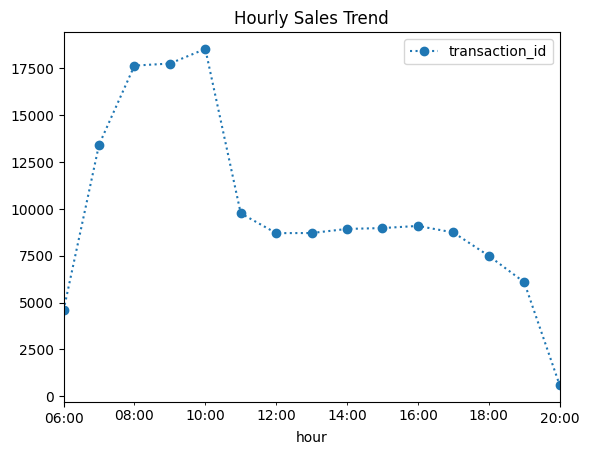

In [4]:
#1 transaction counts vary by hour of the day? Plot a line chart.
df['hour'] = df['time'].dt.to_period('h')
df.pivot_table(index='hour',values='transaction_id',
               aggfunc='nunique').plot(kind='line',
                                       title='Hourly Sales Trend',
                                       marker='o',
                                       linestyle=':'
)

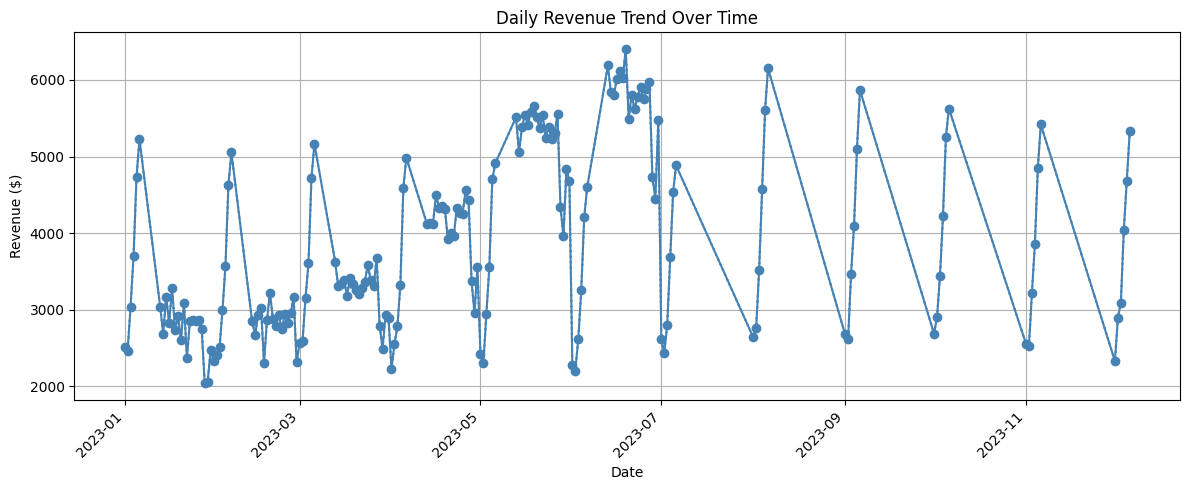

In [5]:
#2 the daily revenue trend over time
df.groupby('date')['revenue'].sum().plot(kind='line',
                                         marker='+',linestyle=':',
                                         title='any',xlabel='any',
                                         ylabel='any')
df.groupby('date')['revenue'].sum().plot(
    kind='line',
    marker='o',          # circle markers
    linestyle='-',       # solid line
    color='steelblue',
    figsize=(12,5),
    title='Daily Revenue Trend Over Time',
    xlabel='Date',
    ylabel='Revenue ($)',
    grid=True            # adds grid lines ✅
)
plt.xticks(rotation=45)
plt.tight_layout()

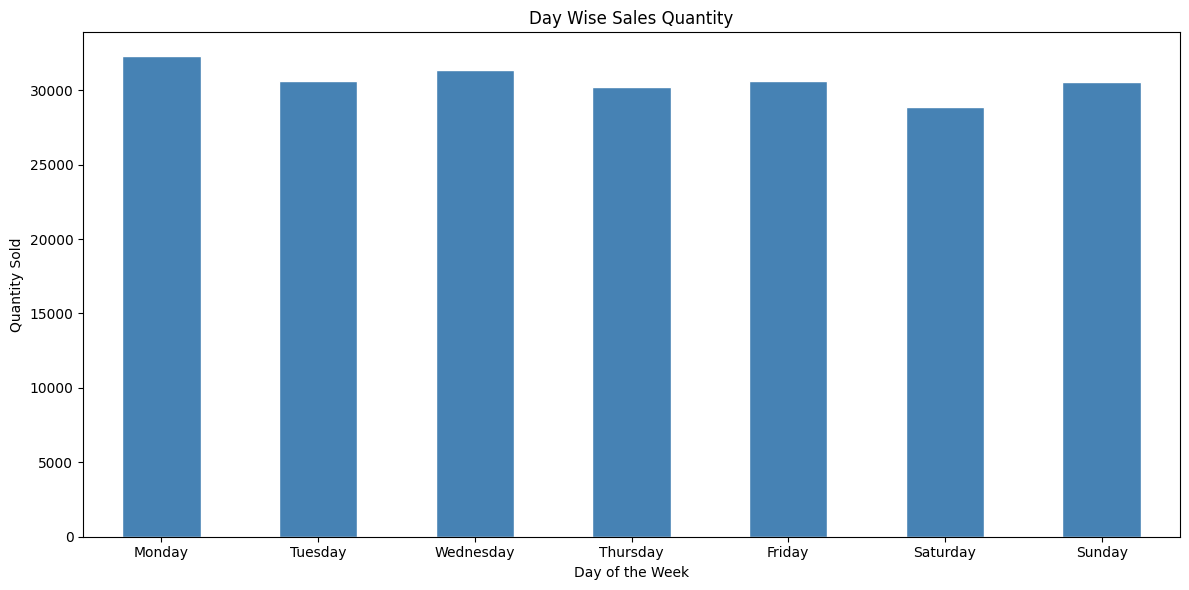

In [6]:
# #3 sales quantities change across different days of the week
# df.groupby('dayname')['transaction_qty'].sum().plot(
#     kind='bar',
#     title='Day Wise Sales Quantiy',
#     xlabel='Day of the Week',
#     ylabel='Quantity Sold',
#     figsize=(12,6)
# )

# plt.tight_layout()

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

df.groupby('dayname')['transaction_qty'].sum()\
  .reindex(day_order)\
  .plot(
    kind='bar',
    title='Day Wise Sales Quantity',
    xlabel='Day of the Week',
    ylabel='Quantity Sold',
    figsize=(12,6),
    color='steelblue',
    edgecolor='white',
    rot=0              # no rotation needed for day names
)

plt.tight_layout()

hour,2026-06-04 06:00,2026-06-04 07:00,2026-06-04 08:00,2026-06-04 09:00,2026-06-04 10:00,2026-06-04 11:00,2026-06-04 12:00,2026-06-04 13:00,2026-06-04 14:00,2026-06-04 15:00,2026-06-04 16:00,2026-06-04 17:00,2026-06-04 18:00,2026-06-04 19:00,2026-06-04 20:00
store_location,,,,,,,,,,,,,,,
Astoria,0,4181,4966,5083,5291,3413,3438,3456,3319,3423,3599,3402,3463,3565,0
Hell's Kitchen,1676,3455,6909,6767,6957,3598,2442,2625,2754,2505,2691,2818,2608,2402,528
Lower Manhattan,2918,5792,5779,5914,6297,2755,2828,2633,2860,3051,2803,2525,1427,125,75


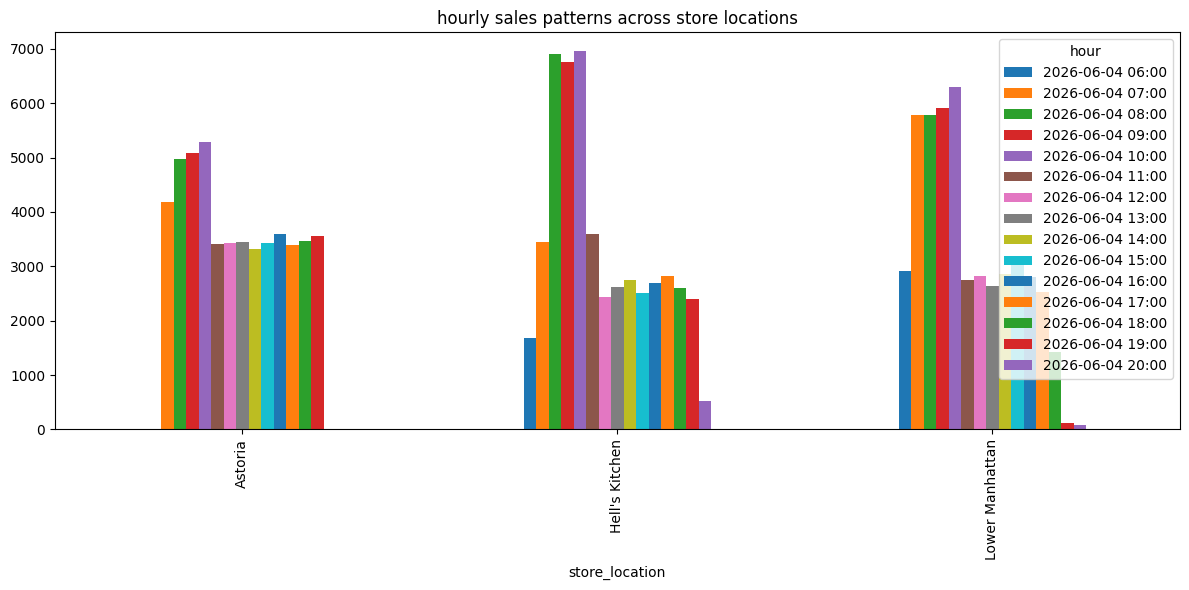

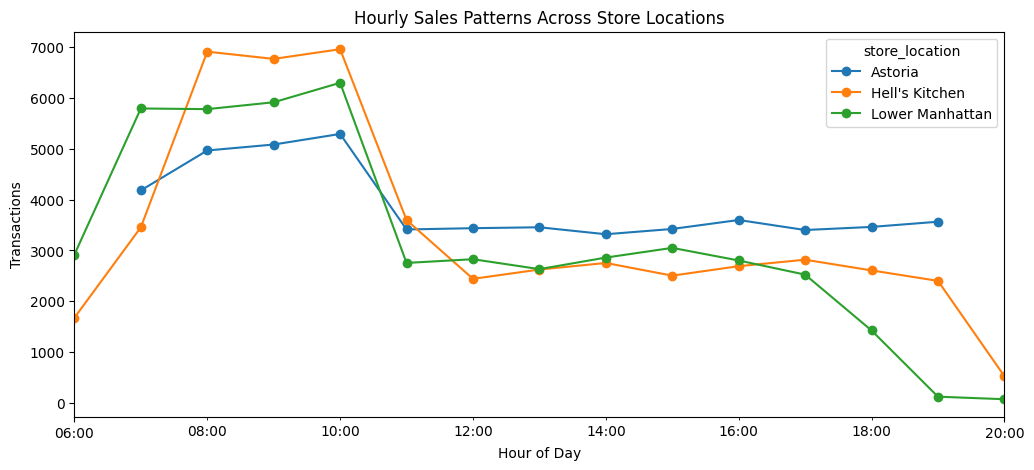

In [7]:
#7 hourly sales patterns across store locations using line plots.

pt = df.pivot_table(index='store_location',columns='hour',
               values='transaction_id',aggfunc='nunique')
pt.plot(kind='bar',figsize=(12,6),title='hourly sales patterns across store locations')

plt.tight_layout()

pt.T.plot(kind='line', figsize=(12,5), marker='o',
          title='Hourly Sales Patterns Across Store Locations',
          xlabel='Hour of Day',
          ylabel='Transactions')
# .T = transpose so hour becomes x-axis ✅#must do for hour as x axis



g = df.groupby(['store_location','hour'])['transaction_id'].nunique()
g = g.unstack(fill_value=0)
g

In [8]:
g = df.groupby(['store_location','hour'])['transaction_id'].nunique().unstack()

# std() measures how much values vary ✅
g.std(axis=1).sort_values()

store_location
Astoria             730.498706
Hell's Kitchen     1941.309009
Lower Manhattan    1967.176689
dtype: float64

In [9]:
# std/mean = coefficient of variation
# accounts for store size difference ✅
(g.std(axis=1) / g.mean(axis=1)).sort_values()

store_location
Astoria            0.187681
Hell's Kitchen     0.573956
Lower Manhattan    0.617547
dtype: float64

In [10]:
#9 stacked bar chart of product category sales per store
#df.groupby('store_location')['product_category'].value_counts().unstack().plot(kind='bar',stacked=True)

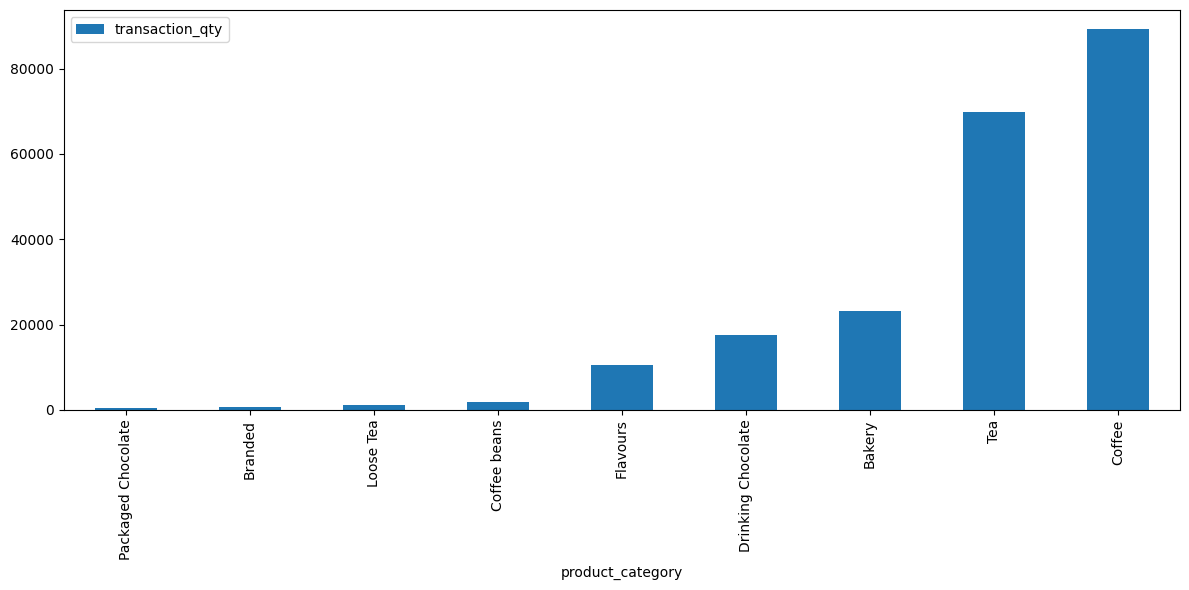

In [11]:
best_selling_prod = df.pivot_table(index='product_category',values='transaction_qty',aggfunc='sum')
best_selling_prod.sort_values('transaction_qty').head(10).plot(kind='bar',figsize=(12,6))
plt.tight_layout()

(array([1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(1, 0, 'Bakery'),
  Text(2, 0, 'Branded'),
  Text(3, 0, 'Coffee'),
  Text(4, 0, 'Coffee beans'),
  Text(5, 0, 'Drinking Chocolate'),
  Text(6, 0, 'Flavours'),
  Text(7, 0, 'Loose Tea'),
  Text(8, 0, 'Packaged Chocolate'),
  Text(9, 0, 'Tea')])

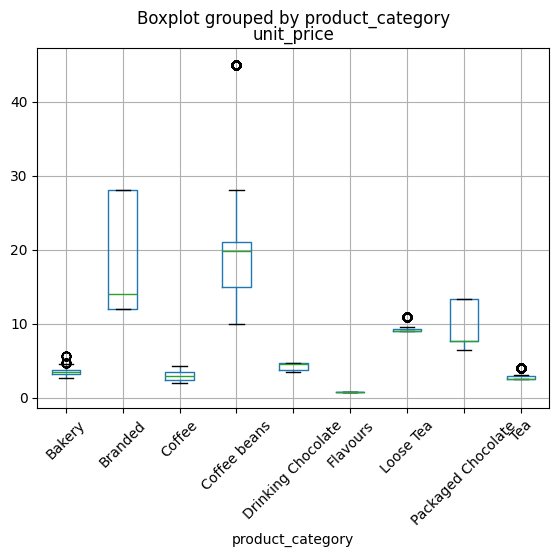

In [12]:
df.boxplot(by='product_category',column='unit_price')
plt.xticks(rotation=45)

<Axes: xlabel='hour', ylabel='day_n'>

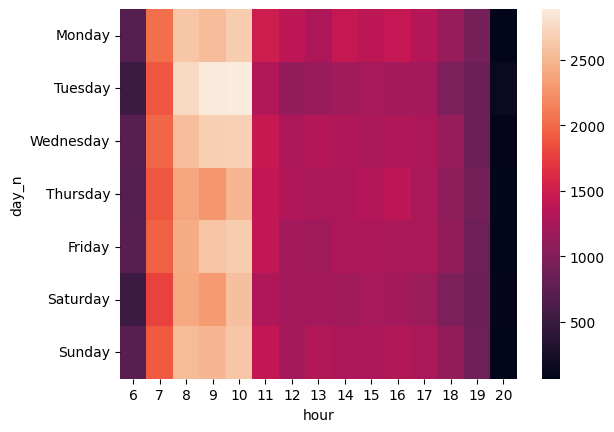

In [45]:
# 19 heatmap of transactions by hour vs day of week
index_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_n'] = df['date'].dt.day_name()
df['hour'] = df['time'].dt.hour
content = df.pivot_table(index='day_n',columns='hour',values='transaction_id',aggfunc='nunique').reindex(index_order)
sns.heatmap(content)

<Axes: xlabel='hour', ylabel='store_location-product_category'>

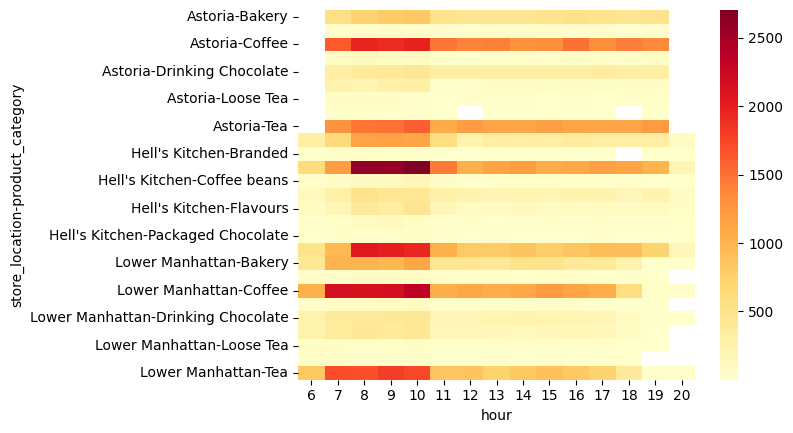

In [ ]:
#20 store-wise hourly demand patterns using heatmaps
values = df.pivot_table(index=['product_category'],columns=['hour'],values='transaction_id',aggfunc='nunique')
sns.heatmap(values,cmap='YlOrRd')

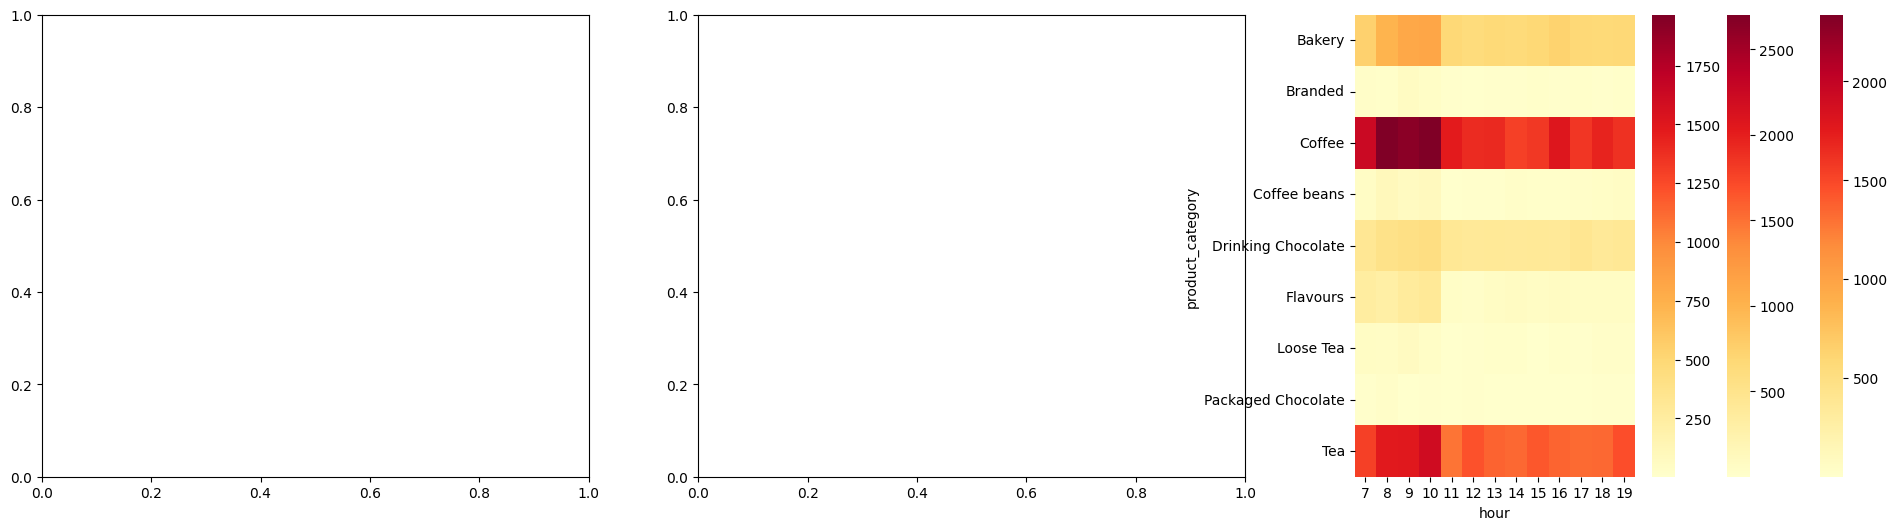

In [59]:
#3 separate are 
locations = df['store_location'].unique()
fig,axes = plt.subplots(1,3,figsize=(24,6))
for i,location in enumerate(locations):
    #filter data for each store
    store_df = df[df['store_location'] == location]
    values = store_df.pivot_table(index='product_category',
                                  columns='hour',
                                  values='transaction_id',
                                  aggfunc='nunique')
    sns.heatmap(values,cmap='YlOrRd')

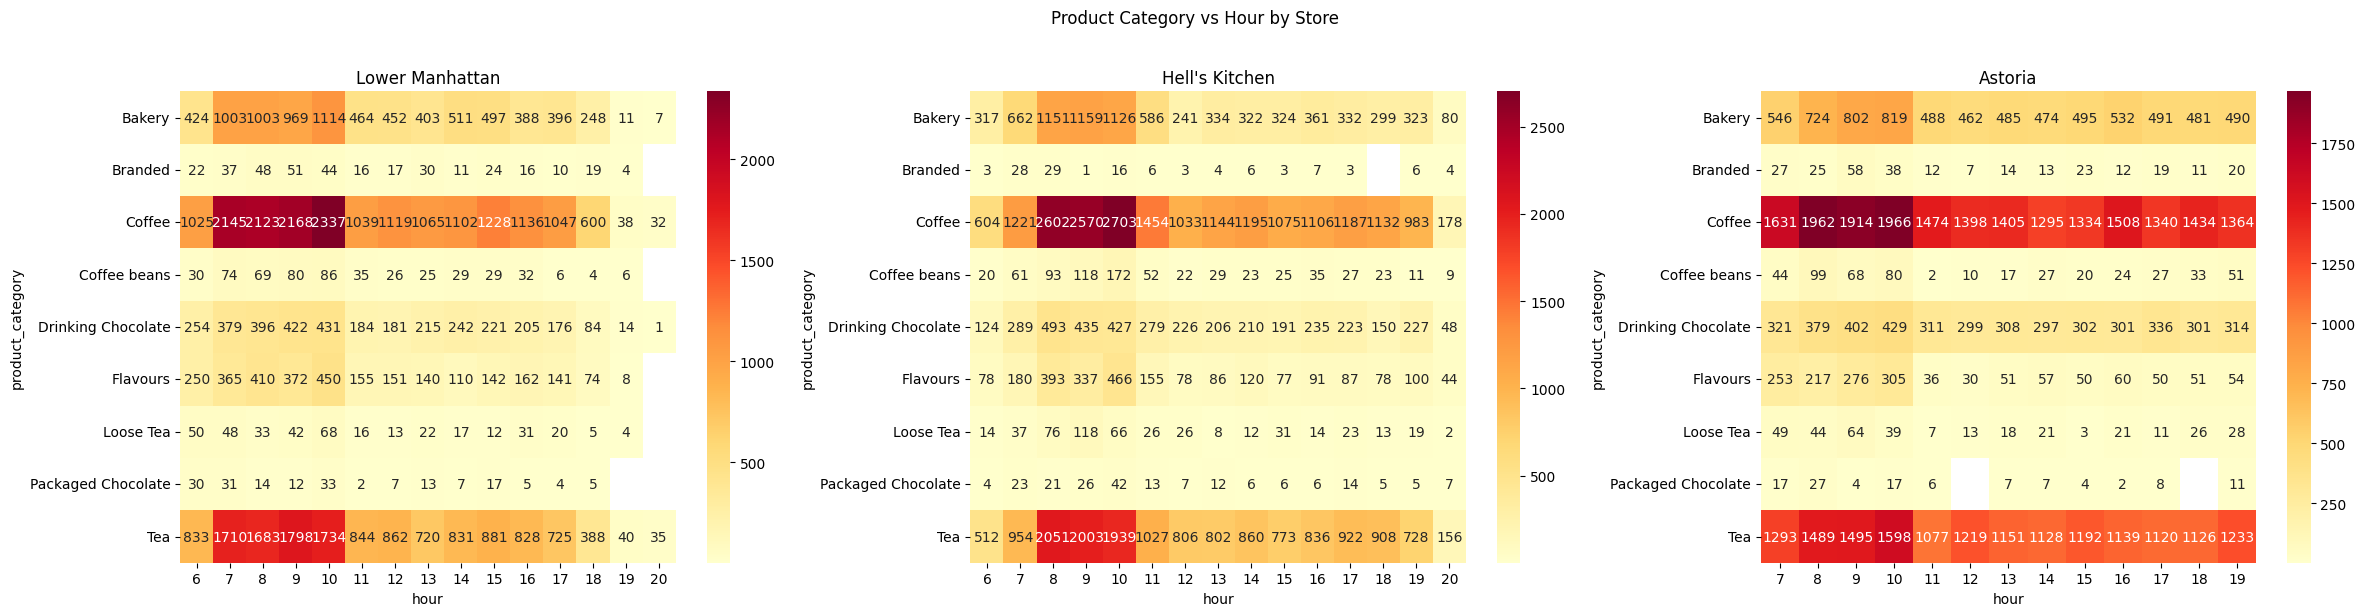

In [ ]:
locations = df['store_location'].unique()  # get all store names

fig, axes = plt.subplots(1,3, figsize=(24, 6))

for i, location in enumerate(locations):
    # filter data for each store
    store_df = df[df['store_location'] == location]
    
    values = store_df.pivot_table(index='product_category',
                                   columns='hour',
                                   values='transaction_id',
                                   aggfunc='nunique')
    
    sns.heatmap(values,
                cmap='YlOrRd',
                annot=True,
                fmt='g',
                ax=axes[i])        # ✅ plot on correct subplot
    
    axes[i].set_title(f'{location}')  # each heatmap gets store name

plt.suptitle('Product Category vs Hour by Store', y=1.02)
plt.tight_layout()

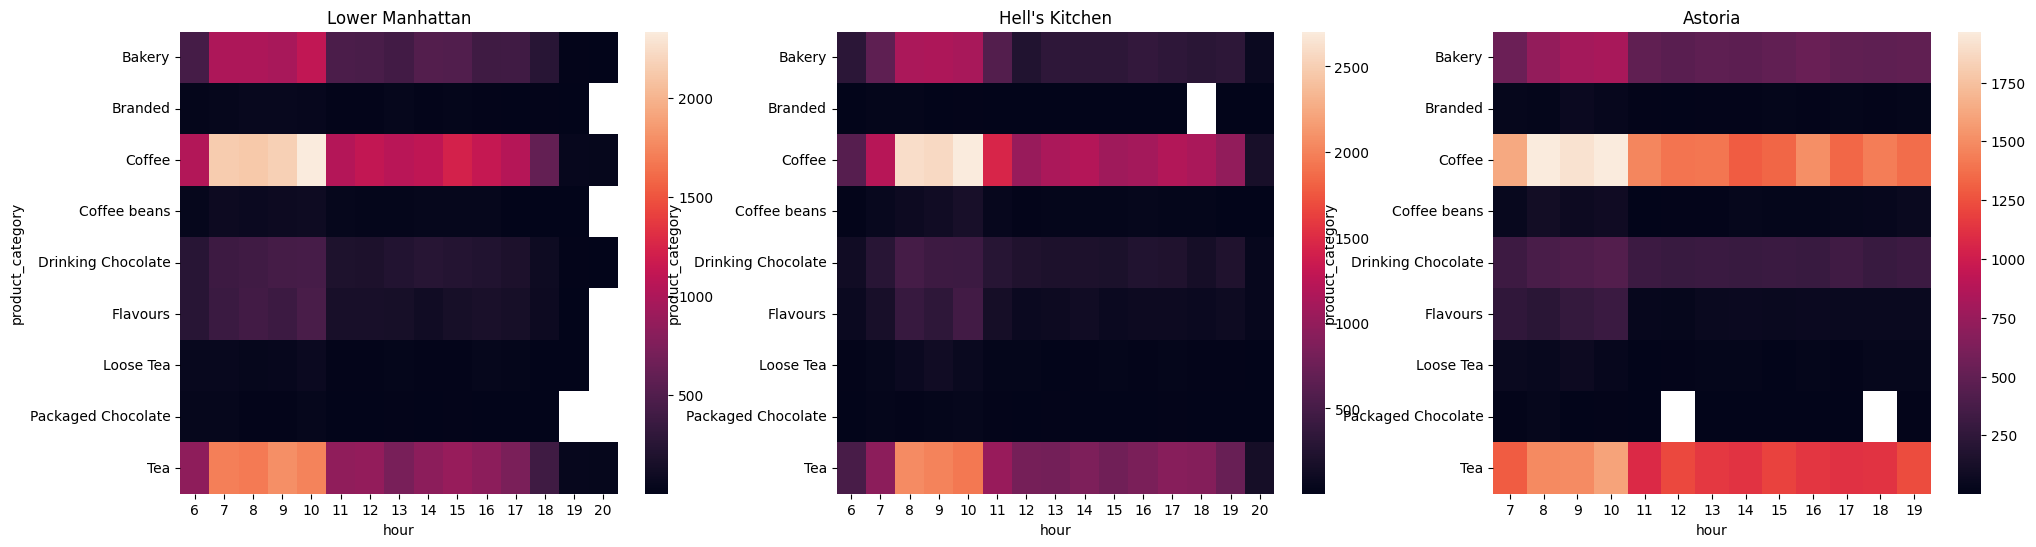

In [74]:
stores = df['store_location'].unique()
fig, axes = plt.subplots(1,3,figsize=(24,6))

for i,store in enumerate(stores):
    store_df = df[df['store_location'] == store]
    
    values = store_df.pivot_table(index='product_category',
                                  columns='hour',
                                  values='transaction_id',
                                  aggfunc='nunique')
    sns.heatmap(values,ax=axes[i])
    axes[i].set_title(f'{store}')


<Axes: xlabel='hour'>

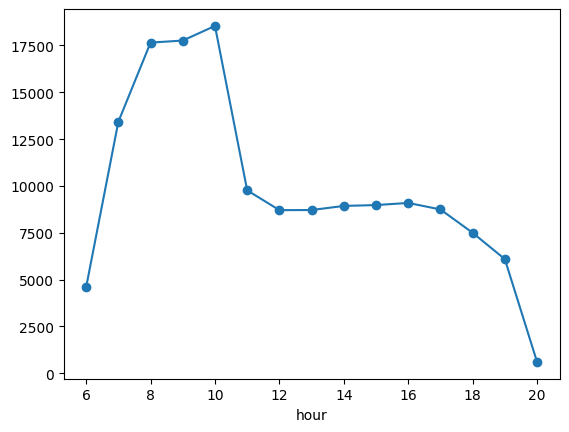

In [80]:
#21 peak congestion hours across all store visually
df.groupby('hour')['transaction_id'].nunique().plot(marker='o')

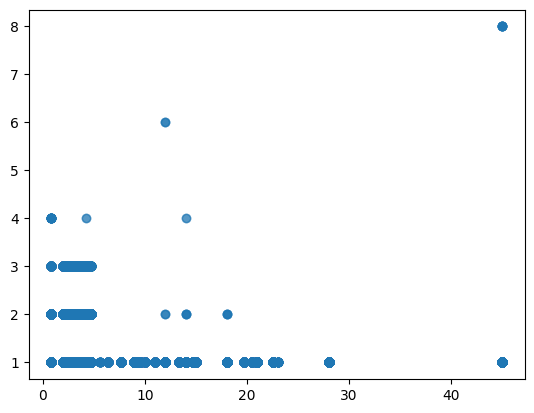

In [88]:
#22 correlation between quantity and unit price using scatter plot.
plt.scatter(x=df['unit_price'],y=df['transaction_qty'],alpha=0.5)


Text(0, 0.5, 'Transaction Quantity')

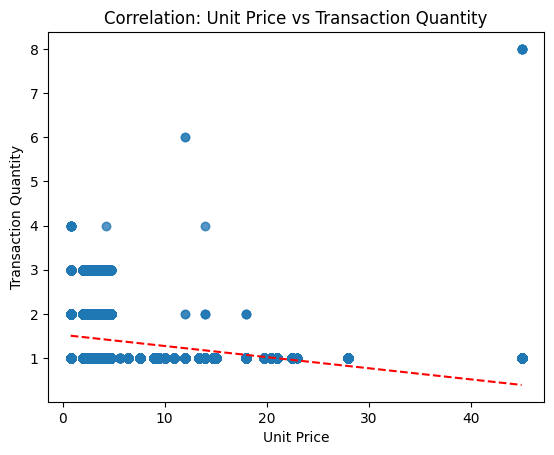

In [89]:
import numpy as np

plt.scatter(x=df['unit_price'], y=df['transaction_qty'], alpha=0.5)

# add trend line
z = np.polyfit(df['unit_price'], df['transaction_qty'], 1)
p = np.poly1d(z)
plt.plot(sorted(df['unit_price']), p(sorted(df['unit_price'])),
         color='red', linestyle='--')  # ✅ shows trend clearly

plt.title('Correlation: Unit Price vs Transaction Quantity')
plt.xlabel('Unit Price')
plt.ylabel('Transaction Quantity')

<Axes: xlabel='unit_price', ylabel='transaction_qty'>

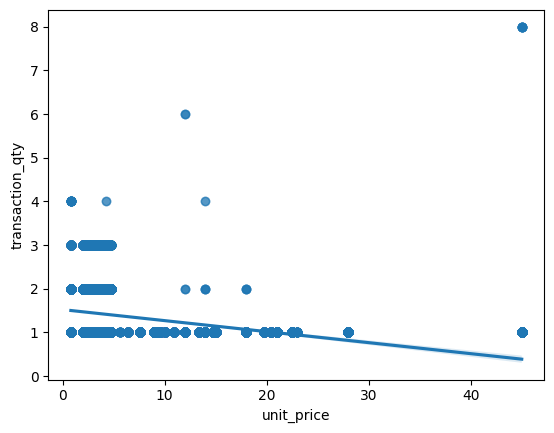

In [ ]:
sns.regplot(data=df, x='unit_price', y='transaction_qty',
            scatter_kws={'alpha':0.5})

# ✅ scatter + trend line in one line!